In [2]:
from utils.util_sample_stuff import *
from utils.util_octree_stuff import *
from utils.util_dualoctree import *

In [3]:
import os
import torch
import torch
import torch.nn.functional as F

def build_ddpm_sampling_buffers(T, device, beta_start=1e-4, beta_end=2e-2):
    """Extend your linear schedule with helpful arrays for sampling."""
    betas = torch.linspace(beta_start, beta_end, T, dtype=torch.float32, device=device)
    alphas = 1.0 - betas
    alphas_cumprod = torch.cumprod(alphas, dim=0)
    alphas_cumprod_prev = torch.cat([torch.ones(1, device=device), alphas_cumprod[:-1]], dim=0)

    sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
    sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)
    sqrt_recip_alphas = torch.sqrt(1.0 / alphas)

    # posterior q(x_{t-1}|x_t, x0)
    posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)
    # clip log var for t=0 (same trick as OpenAI / LDM)
    posterior_log_variance_clipped = torch.log(torch.clamp(posterior_variance, min=1e-20))
    posterior_mean_coef1 = betas * torch.sqrt(alphas_cumprod_prev) / (1.0 - alphas_cumprod)
    posterior_mean_coef2 = (1.0 - alphas_cumprod_prev) * torch.sqrt(alphas) / (1.0 - alphas_cumprod)

    sched = {
        "betas": betas,
        "alphas": alphas,
        "alphas_cumprod": alphas_cumprod,
        "alphas_cumprod_prev": alphas_cumprod_prev,
        "sqrt_alphas_cumprod": sqrt_alphas_cumprod,
        "sqrt_one_minus_alphas_cumprod": sqrt_one_minus_alphas_cumprod,
        "sqrt_recip_alphas": sqrt_recip_alphas,
        "posterior_variance": posterior_variance,
        "posterior_log_variance_clipped": posterior_log_variance_clipped,
        "posterior_mean_coef1": posterior_mean_coef1,
        "posterior_mean_coef2": posterior_mean_coef2,
    }
    return sched

def _extract(a, t, x_shape):
    """
    a: [T], t: [B], x_shape: e.g. (B,C,D,H,W)
    returns [B,1,1,1,1] broadcastable to x
    """
    out = a.gather(0, t)
    return out.view(-1, *([1] * (len(x_shape) - 1)))

@torch.no_grad()
def p_mean_variance_eps(model, x_t, t, sched):
    """
    Predict posterior mean & variance using ε-prediction.
    Returns: mean, log_variance, x0_pred
    """
    # eps_theta
    eps_theta = model(x_t, timesteps=t)

    sqrt_alphabar_t = _extract(sched["sqrt_alphas_cumprod"], t, x_t.shape)
    sqrt_one_minus_alphabar_t = _extract(sched["sqrt_one_minus_alphas_cumprod"], t, x_t.shape)

    # x0 prediction from eps
    x0_pred = (x_t - sqrt_one_minus_alphabar_t * eps_theta) / (sqrt_alphabar_t + 1e-8)

    # posterior mean
    c1 = _extract(sched["posterior_mean_coef1"], t, x_t.shape)
    c2 = _extract(sched["posterior_mean_coef2"], t, x_t.shape)
    mean = c1 * x0_pred + c2 * x_t

    # posterior variance (log)
    log_variance = _extract(sched["posterior_log_variance_clipped"], t, x_t.shape)
    return mean, log_variance, x0_pred

@torch.no_grad()
def sample_ddpm(model, sched, shape, T=1000, device="cuda", x_T=None):
    """
    Classic ancestral DDPM sampling (full 1000 steps).
    - model: ε-pred UNet that accepts integer t in [0..T-1]
    - sched: dict from build_ddpm_sampling_buffers(...)
    - shape: (B,C,D,H,W)
    - x_T: optional starting noise [B,C,D,H,W]
    """
    if x_T is None:
        x_t = torch.randn(shape, device=device)
    else:
        x_t = x_T.to(device)

    model.eval()
    for t_int in reversed(range(T)):
        t = torch.full((shape[0],), t_int, device=device, dtype=torch.long)

        mean, log_var, x0_pred = p_mean_variance_eps(model, x_t, t, sched)

        if t_int > 0:
            noise = torch.randn_like(x_t)
            x_t = mean + torch.exp(0.5 * log_var) * noise
        else:
            # final step: return the x_0 estimate (mean is fine too)
            x_t = x0_pred
    return x_t
import torch

def split2splitbig(split: torch.Tensor) -> torch.Tensor:
    """
    Expand an octant-coded grid into a dense grid with a singleton channel.

    Input:
        split: [B, 8, L, L, L]
            Channels 0..7 map to (e/o) along (z, y, x) respectively.

    Output:
        split_big: [B, 1, 2L, 2L, 2L]
    """
    assert split.ndim == 5, f"Expected [B, 8, L, L, L], got {split.shape}"
    B, C, L, H, W = split.shape
    assert C == 8, f"Channel dimension must be 8, got {C}"

    split_big = torch.full((B, 1, 2*L, 2*H, 2*W), -1, dtype=split.dtype, device=split.device)

    # Work on the single output channel
    sb = split_big[:, 0]

    # Fill each octant
    sb[:, 0::2, 0::2, 0::2] = split[:, 0]  # (e,e,e)
    sb[:, 0::2, 0::2, 1::2] = split[:, 1]  # (e,e,o)
    sb[:, 0::2, 1::2, 0::2] = split[:, 2]  # (e,o,e)
    sb[:, 0::2, 1::2, 1::2] = split[:, 3]  # (e,o,o)
    sb[:, 1::2, 0::2, 0::2] = split[:, 4]  # (o,e,e)
    sb[:, 1::2, 0::2, 1::2] = split[:, 5]  # (o,e,o)
    sb[:, 1::2, 1::2, 0::2] = split[:, 6]  # (o,o,e)
    sb[:, 1::2, 1::2, 1::2] = split[:, 7]  # (o,o,o)

    return split_big




import torch

def splitbig2split(split_big: torch.Tensor) -> torch.Tensor:
    """
    Collapse a dense voxel grid back into an octant-coded tensor.

    Accepts:
        [B, 1, 2L, 2L, 2L]  or  [B, 2L, 2L, 2L]
    Returns:
        [B, 8, L, L, L]
    """
    if split_big.ndim == 5:
        B, C, D, H, W = split_big.shape
        assert C == 1, f"Expected channel=1, got {C}"
        sb = split_big[:, 0]
    elif split_big.ndim == 4:
        B, D, H, W = split_big.shape
        sb = split_big
    else:
        raise AssertionError(f"Expected [B,1,2L,2L,2L] or [B,2L,2L,2L], got {split_big.shape}")

    assert D % 2 == 0 and H % 2 == 0 and W % 2 == 0, "Spatial dims must be even"
    L = D // 2

    out = torch.empty((B, 8, L, L, L), dtype=sb.dtype, device=sb.device)
    out[:, 0] = sb[:, 0::2, 0::2, 0::2]  # (e,e,e)
    out[:, 1] = sb[:, 0::2, 0::2, 1::2]  # (e,e,o)
    out[:, 2] = sb[:, 0::2, 1::2, 0::2]  # (e,o,e)
    out[:, 3] = sb[:, 0::2, 1::2, 1::2]  # (e,o,o)
    out[:, 4] = sb[:, 1::2, 0::2, 0::2]  # (o,e,e)
    out[:, 5] = sb[:, 1::2, 0::2, 1::2]  # (o,e,o)
    out[:, 6] = sb[:, 1::2, 1::2, 0::2]  # (o,o,e)
    out[:, 7] = sb[:, 1::2, 1::2, 1::2]  # (o,o,o)
    return out

def save_checkpoint(path, model, optimizer=None, scheduler=None, ema=None,
                    epoch=0, global_step=0, extra: dict | None=None):
    ckpt = {
        "model": model.state_dict(),
        "epoch": epoch,
        "global_step": global_step,
    }
    if optimizer is not None:
        ckpt["optimizer"] = optimizer.state_dict()
    if scheduler is not None:
        ckpt["scheduler"] = scheduler.state_dict()
    if ema is not None:
        # store EMA shadow weights
        ckpt["ema_shadow"] = {k: v.clone().cpu() for k, v in ema.shadow.items()}
        ckpt["ema_decay"] = ema.decay
    if extra:
        ckpt["extra"] = extra
    os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
    torch.save(ckpt, path)
    print(f"[+] Saved checkpoint to {path}")

def load_checkpoint(path, model, optimizer=None, scheduler=None, ema=None,
                    map_location="cpu", strict=True):
    ckpt = torch.load(path, map_location=map_location)
    model.load_state_dict(ckpt["model"], strict=strict)
    print(f"[+] Loaded model weights from {path}")

    if optimizer is not None and "optimizer" in ckpt:
        optimizer.load_state_dict(ckpt["optimizer"])
        print("[+] Loaded optimizer state")
    if scheduler is not None and "scheduler" in ckpt:
        scheduler.load_state_dict(ckpt["scheduler"])
        print("[+] Loaded scheduler state")
    if ema is not None and "ema_shadow" in ckpt:
        # ensure keys match; if model changed, set strict=False earlier
        ema.shadow = {k: v.to(next(model.parameters()).device) for k, v in ckpt["ema_shadow"].items()}
        if "ema_decay" in ckpt:
            ema.decay = ckpt["ema_decay"]
        print("[+] Loaded EMA shadow")

    epoch = ckpt.get("epoch", 0)
    global_step = ckpt.get("global_step", 0)
    extra = ckpt.get("extra", {})
    return epoch, global_step, extra
def voxel_to_patch(vox, patch_size=8):
    """
    Input:
        vox: [B, H, W, D] = [B, 128, 128, 32]
    Output:
        [B, H//p, W//p, D, p, p] = [B, 32, 32, 32, 4, 4]
    """
    B, H, W, D = vox.shape
    P = patch_size
    assert H % P == 0 and W % P == 0, "Height/Width must be divisible by patch size"

    vox = vox.view(B, H//P, P, W//P, P, D)               # [B, 32, 4, 32, 4, D]
    vox = vox.permute(0, 1, 3, 5, 2, 4)                  # [B, 32, 32, D, 4, 4]
    return vox  # [B, 32, 32, D, 4, 4]
def patch_to_voxel(patches):
    """
    Input:
        patches: [B, 32, 32, 32, 4, 4]
    Output:
        [B, 128, 128, 32]
    """
    B, H, W, D, p1, p2 = patches.shape
    assert p1 == p2, "patch must be square"

    vox = patches.permute(0, 1, 4, 2, 5, 3)              # [B, 32, 4, 32, 4, D]
    vox = vox.reshape(B, H * p1, W * p2, D)              # [B, 128, 128, D]
    return vox
def get_non_empty_mask(vox, patch_size=8):
    """
    Input:
        vox: [128, 128, 32]
    Output:
        mask: [32, 32, 32] (bool), True if corresponding 4x4 patch contains nonzero
    """
    H, W, D = vox.shape
    P = patch_size
    assert H % P == 0 and W % P == 0

    # reshape to group patches
    vox_reshaped = vox.view(H//P, P, W//P, P, D)           # [32, 4, 32, 4, 32]
    vox_reshaped = vox_reshaped.permute(0, 2, 4, 1, 3)     # [32, 32, 32, 4, 4]

    # check if any voxel in each patch is non-zero
    mask = (vox_reshaped != 0).any(dim=(-1, -2))           # [32, 32, 32]
    return mask




In [4]:
from models.networks.dualoctree_networks.graph_sem_vae import GraphVAE
DEPTH_STOP = 6
LATENT_DIM = 8
FULL_DEPTH = 3
vae = GraphVAE(
    depth=6,
    channel_in=32,     
    nout=2,
    full_depth=FULL_DEPTH,
    depth_stop=DEPTH_STOP ,
    depth_out=6,
    latent_dim=LATENT_DIM,  
    num_classes=21,# latent dimension
    resblk_num=1,
    
).cuda()

vae.load_state_dict(torch.load("/home/brendan/SemCityOcto/vae_fdepth6_ldim8_8.pt"),vae.parameters())

vae.eval() 

import torch
from models.networks.dualoctree_networks.dual_octree import DualOctree
from models.networks.diffusion_networks.graph_unet_hr import UNet3DModel

# === 1. Hyperparams ===
in_channels = LATENT_DIM        # dimension of latent z
model_channels = 64

lr_model_channels = 128
out_channels = LATENT_DIM      # same as input if predicting noise
image_size = 16
depth = DEPTH_STOP
full_depth = FULL_DEPTH
channel_mult = [2,4]
num_res_blocks = [2, 2, 2]



# === 4. Init and forward model ===
unet_model = UNet3DModel(
    image_size=image_size,
    input_depth=depth,
    full_depth=full_depth,
    in_channels=in_channels,
    model_channels=model_channels,
    lr_model_channels=lr_model_channels,
    out_channels=out_channels,
    num_res_blocks=num_res_blocks,
    dropout=0.1,
    channel_mult=channel_mult,
    use_checkpoint=False,
).cuda()

unet_model.load_state_dict(torch.load("Model_is_good_8_6.pt"),unet_model.parameters())
unet_model.eval()
from models.networks.diffusion_networks.graph_unet_lr import UNet3DModel
batch_size = 1
in_channels = 1

full_depth = 4  # dummy value, used only in forward_as_middle
model_channels = 64
out_channels = 1



structure_model = UNet3DModel(
    full_depth=full_depth,
    in_split_channels=in_channels,
    model_channels=model_channels,
    out_split_channels=out_channels,
    channel_mult=(1, 2, 4,8),
    attention_resolutions=[2, 4, 8],  # example downsample scales
    dims=3,  # 3D model
    num_heads=4,
    timestep_repr = "ddpm",
    T = 1000,
).cuda()

epoch, global_step, _ = load_checkpoint(
    "checkpoints/structure_ddpm_ep110.pt",
    model=structure_model,
    map_location="cuda",     # or your device
    strict=True,
)


/tmp/ipykernel_409201/169080356.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vae.load_state_dict(torch.load("/home/brendan/SemCityOcto/vae_fdepth6_ldim8_8.pt"),vae.p

[+] Loaded model weights from checkpoints/structure_ddpm_ep110.pt


In [5]:
device = next(structure_model.parameters()).device
sched = build_ddpm_sampling_buffers(T=1000, device=device, beta_start=1e-4, beta_end=2e-2)



In [5]:
import os
import torch

# Make sure the output directory exists
output_dir = './split_outputs'
os.makedirs(output_dir, exist_ok=True)
OFFSET = 0  # you must define this based on your needs
cnt = 0
from dataset.velodyne_to_voxel import velodene_to_voxel

# try both 0 and 90
gt = velodene_to_voxel( "/home/brendan/SemCityOcto/dataset/", "00", "000890")
real_mask = gt != 0
vox = torch.tensor(real_mask).unsqueeze(0)


# vox[invalid == 1] = 0
# vox[vox == 255] = 0

patch = voxel_to_patch(vox, 4)
vox_recon = patch_to_voxel(patch)

non_empty_mask = get_non_empty_mask(vox[0], 4)
non_empty_mask_padded = torch.zeros((64, 64, 64))

non_empty_mask_padded[:, :, OFFSET:OFFSET + 32] = non_empty_mask

points = voxel_grid_to_points(non_empty_mask_padded)
octree = points2octree(points, depth=6, full_depth=3)

split = octree2split_small(octree, 4)
split_cut = split[:, :, :, :, 0:8]  # shape: [C, D, H, W, 8]

split_cut[split_cut == -1] = 0
# split_cut[split_cut == 1] = 1
# Save to file with counter
save_path = os.path.join(output_dir, f"split_cut_{cnt:08d}.pt")
torch.save(split_cut, save_path)

#     cnt += 1

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Loading data for sequence 00, scan 000890...


In [6]:
visualize_kitti_instance(torch.tensor(gt).cuda())

/home/brendan/SemCityOcto/util_octree_stuff.py:539: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [7]:
gt_clone = torch.tensor(gt).clone()
gt_clone[gt_clone != 0] = 20
visualize_kitti_instance(torch.tensor(gt_clone).cuda())

/tmp/ipykernel_398693/2419494006.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  visualize_kitti_instance(torch.tensor(gt_clone).cuda())


In [6]:
import numpy as np
from numba import njit, prange

# occupancy: int8 array with values {-1: unknown, 0: free, 1: occupied}
# grid shape: (H, W, D) e.g., (256, 256, 32)
# origin: (ox, oy, oz) integer voxel indices
# hits: int32 array of shape [N, 3], each row (x, y, z) is an occupied voxel to backtrace from.

@njit(cache=True)
def _dda_trace_mark_free(occ, ox, oy, oz, hx, hy, hz):
    """
    3D DDA from hit voxel (hx,hy,hz) toward origin (ox,oy,oz).
    Turns any -1 encountered into 0. Stops when reaching a 0 (already free) or origin.
    """
    x, y, z = hx, hy, hz
    if x == ox and y == oy and z == oz:
        return

    # Direction (from hit -> origin), step per axis
    dx = ox - x
    dy = oy - y
    dz = oz - z

    step_x = 0 if dx == 0 else (1 if dx > 0 else -1)
    step_y = 0 if dy == 0 else (1 if dy > 0 else -1)
    step_z = 0 if dz == 0 else (1 if dz > 0 else -1)

    # Work in "cell-center coordinates"
    # Current point at center: (x+0.5, y+0.5, z+0.5)
    # Ray direction as floats:
    rdx = float(dx)
    rdy = float(dy)
    rdz = float(dz)

    # Avoid division by zero
    inv_rdx = 1.0 / abs(rdx) if dx != 0 else 1e30
    inv_rdy = 1.0 / abs(rdy) if dy != 0 else 1e30
    inv_rdz = 1.0 / abs(rdz) if dz != 0 else 1e30

    # Distance (in param t) to the first grid boundary in each axis
    # From center to the boundary we’ll cross first, measured along ray paramization.
    # Center offset to next boundary is 0.5 toward the step direction.
    tMaxX = 0.5 * inv_rdx if dx != 0 else 1e30
    tMaxY = 0.5 * inv_rdy if dy != 0 else 1e30
    tMaxZ = 0.5 * inv_rdz if dz != 0 else 1e30

    # Delta t between crossings in each axis (how far between voxel boundaries)
    tDeltaX = 1.0 * inv_rdx
    tDeltaY = 1.0 * inv_rdy
    tDeltaZ = 1.0 * inv_rdz

    H, W, D = occ.shape

    # March until we reach origin
    while not (x == ox and y == oy and z == oz):
        # Mark unknown as free
        if 0 <= x < H and 0 <= y < W and 0 <= z < D:
            if occ[x, y, z] == -1:
                occ[x, y, z] = 0
            elif occ[x, y, z] == 0:
                # already free; remaining to origin must have been carved already
                break
        else:
            # Out of bounds; bail
            break

        # Advance in the axis with smallest next boundary distance
        if tMaxX <= tMaxY and tMaxX <= tMaxZ:
            x += step_x
            tMaxX += tDeltaX
        elif tMaxY <= tMaxX and tMaxY <= tMaxZ:
            y += step_y
            tMaxY += tDeltaY
        else:
            z += step_z
            tMaxZ += tDeltaZ

    # Optionally: we do not change the hit or origin cells themselves here.
    # If you want the origin to be forced free:
    # if 0 <= ox < H and 0 <= oy < W and 0 <= oz < D and occ[ox,oy,oz] == -1:
    #     occ[ox,oy,oz] = 0


@njit(parallel=True, cache=True)
def carve_free_from_hits(occ, origin, hits_sorted):
    ox, oy, oz = origin
    n = hits_sorted.shape[0]
    for i in prange(n):
        hx, hy, hz = hits_sorted[i, 0], hits_sorted[i, 1], hits_sorted[i, 2]
        _dda_trace_mark_free(occ, ox, oy, oz, hx, hy, hz)


def reverse_ray_trace(occupancy, origin, hits):
    """
    occupancy: np.int8 [H,W,D], values in {-1,0,1}
    origin: (ox,oy,oz) ints
    hits: np.int32 [N,3], indices of occupied voxels to backtrace from (these should be 1s in occupancy)
    Returns: occupancy modified in-place.
    """
    # Sort hits far->near to maximize early termination
    ox, oy, oz = origin
    if hits.shape[0] == 0:
        return occupancy
    d2 = (hits[:,0]-ox)**2 + (hits[:,1]-oy)**2 + (hits[:,2]-oz)**2
    order = np.argsort(-d2)  # descending distance
    hits_sorted = hits[order].astype(np.int32)
    carve_free_from_hits(occupancy, np.array(origin, dtype=np.int32), hits_sorted)
    return occupancy
from numba import njit, prange
import numpy as np
import torch

@njit(cache=True)
def _fill_between_ones_1d(arr):
    n = arr.shape[0]
    i = 0
    while i < n:
        while i < n and arr[i] != 1:
            i += 1
        if i >= n:
            break
        j = i + 1
        while j < n and arr[j] != 1:
            j += 1
        if j < n:
            for k in range(i+1, j):
                if arr[k] == 0:   # only fill 0s → 1; leave -1 as unknown
                    arr[k] = 1
        i = j

@njit(parallel=True, cache=True)
def ground_convex_fill_levels(occ, z_levels):
    """
    occ: int8 [H,W,D]
    z_levels: int32 [L] (1D!) of slice indices to fill (e.g., [0,1])
    """
    H, W, D = occ.shape
    L = z_levels.shape[0]
    for zi in range(L):
        z = z_levels[zi]               # scalar int
        if z < 0 or z >= D:
            continue

        # along X for each Y
        for y in prange(W):
            line = occ[:, y, z]        # shape H
            _fill_between_ones_1d(line)

        # along Y for each X
        for x in prange(H):
            line = occ[x, :, z]        # shape W
            _fill_between_ones_1d(line)

def reverse_ray_trace_with_ground_fill(occ, origin, hits, z_levels=(0,1)):
    """
    occ: np.int8 [H,W,D], mutated in place
    origin: (ox,oy,oz)
    hits: np.int32 [N,3]
    z_levels: iterable of ints (e.g., (0,1))
    """
    # ---- your existing reverse ray trace ----
    if hits.size > 0:
        occ[hits[:,0], hits[:,1], hits[:,2]] = 1
    occ = reverse_ray_trace(occ, origin, hits)

    # ---- enforce 1D int32 z_levels for numba ----
    z_levels = np.array(tuple(int(z) for z in z_levels), dtype=np.int32)
    ground_convex_fill_levels(occ, z_levels)
    return occ

In [7]:
import torch
import torch.nn.functional as F

# --- helper: q(x_t | x0) ---
def q_sample(x0, t, sched, noise=None):
    """
    x0:    [B,C,D,H,W]
    t:     [B] int
    noise: [B,C,D,H,W] or None
    """
    if noise is None:
        noise = torch.randn_like(x0)
    sqrt_ab = _extract(sched["sqrt_alphas_cumprod"], t, x0.shape)
    sqrt_omb = _extract(sched["sqrt_one_minus_alphas_cumprod"], t, x0.shape)
    return sqrt_ab * x0 + sqrt_omb * noise

def _maybe_broadcast_mask(mask, x_like):
    """
    mask: [B,1,D,H,W] or [B,C,D,H,W] (float in [0,1])
    returns: [B,C,D,H,W]
    """
    if mask.dim() != x_like.dim():
        raise ValueError(f"mask dim {mask.dim()} must match x dim {x_like.dim()}")
    if mask.shape[1] == 1 and x_like.shape[1] != 1:
        mask = mask.expand(-1, x_like.shape[1], -1, -1, -1)
    return mask

def _feather_mask(mask, ks):
    """Box-blur mask with odd kernel size ks (approx Gaussian)."""
    if ks <= 1:
        return mask
    pad = ks // 2
    # avg_pool3d expects stride=1 + same padding to keep shape
    return F.avg_pool3d(mask, kernel_size=ks, stride=1, padding=pad)

def q_forward_xt_to(xs, t_from, t_to, sched, noise=None, eps=1e-7):
    """
    Multi-step forward diffusion: q(x_{s} | x_{t}) with s>t using ᾱ-ratio.
    xs:    [B,C,D,H,W] at time t_from
    t_from,t_to: [B] longs with t_to >= t_from
    """
    if noise is None:
        noise = torch.randn_like(xs)
    # sqrt ratio = sqrt(ᾱ_{to}) / sqrt(ᾱ_{from})
    sqrt_ab_from = _extract(sched["sqrt_alphas_cumprod"], t_from, xs.shape)
    sqrt_ab_to   = _extract(sched["sqrt_alphas_cumprod"], t_to,   xs.shape)
    sqrt_ratio   = (sqrt_ab_to / (sqrt_ab_from + eps)).clamp(0.0, 1.0)
    # ensure numeric safety
    add_var = (1.0 - sqrt_ratio**2).clamp_min(0.0)
    return sqrt_ratio * xs + add_var.sqrt() * noise
@torch.no_grad()
def sample_ddpm_inpaint_blended(
    model,
    sched,
    x_gt,                  # [B,C,D,H,W] clean ground truth
    mask,                  # [B,1,D,H,W] or [B,C,D,H,W], float {0,1} or [0,1]
    T=1000,
    device="cuda",
    x_T=None,              # optional starting noise [B,C,D,H,W]
    blend_pre=True,        # blend known region before model predicts (recommended)
    blend_post=True,       # blend known region after stepping to t-1 (recommended)
    feather_kernel_max=None,  # e.g., 7 -> large blur early, shrinks over time
):
    """
    DDPM ε-pred inpainting with 'blended diffusion' style clamping.
    - At each step t, we replace known-region with q(x_t | x_gt) (optionally feathered mask).
    - If feather_kernel_max is set (odd int), we use a larger blur early and smaller later.

    Returns: x_0 with known region exactly set to x_gt.
    """
    model.eval()
    x_gt = x_gt.to(device)
    mask = mask.to(device).clamp_(0.0, 1.0)
    mask = _maybe_broadcast_mask(mask, x_gt)

    B, C, D, H, W = x_gt.shape
    if x_T is None:
        x_t = torch.randn((B, C, D, H, W), device=device, dtype=x_gt.dtype)
    else:
        x_t = x_T.to(device, dtype=x_gt.dtype)

    # iterate t = T-1 ... 0
    for t_int in reversed(range(T)):
        
        t = torch.full((B,), t_int, device=device, dtype=torch.long)

        # Optional dynamic feathering (soft mask wider early, tighter later)
        if feather_kernel_max is not None and feather_kernel_max > 1:
            # scale kernel ~ linearly with time; ensure odd >=1
            ks = int(max(1, round(1 + (feather_kernel_max - 1) * (t_int / max(1, T - 1)))))
            if ks % 2 == 0:
                ks += 1
            mask_t = _feather_mask(mask, ks)
        else:
            mask_t = mask

        # Compute the *noised* ground-truth for this t to clamp the known region
        eps_known = torch.randn_like(x_t)
        x_gt_t = q_sample(x_gt, t, sched, noise=eps_known)

        # Pre-blend: ensure model sees correct known-region statistics at time t
        if blend_pre:
            x_t = mask_t * x_gt_t + (1.0 - mask_t) * x_t

        # Predict posterior using ε-pred
        mean, log_var, x0_pred = p_mean_variance_eps(model, x_t, t, sched)

        if t_int > 0:
            noise = torch.randn_like(x_t)
            x_t = mean + torch.exp(0.5 * log_var) * noise

            # Post-blend into x_{t-1}: use t-1 for the clamped known region
            if blend_post:
                t_prev = torch.full((B,), t_int - 1, device=device, dtype=torch.long)
                x_gt_tminus1 = q_sample(x_gt, t_prev, sched)  # fresh noise; ok for known region
                # Feather again at t-1 for smooth annealing
                if feather_kernel_max is not None and feather_kernel_max > 1:
                    ks = int(max(1, round(1 + (feather_kernel_max - 1) * ((t_int - 1) / max(1, T - 1)))))
                    if ks % 2 == 0:
                        ks += 1
                    mask_tminus1 = _feather_mask(mask, ks)
                else:
                    mask_tminus1 = mask
                x_t = mask_tminus1 * x_gt_tminus1 + (1.0 - mask_tminus1) * x_t
        else:
            # Final: return x_0 but *exactly* enforce known region = x_gt
            x_t = mask * x_gt + (1.0 - mask) * x0_pred

    return x_t

def _build_repaint_times(T, jump_length=10, jump_n_sample=10):
    """
    Create a schedule of timesteps t that moves by ±1 each transition,
    inserting zig-zag resampling blocks (forward r, backward r) at multiples of jump_length.
    """
    times = [T - 1]
    t = T - 1
    while t > 0:
        # one normal reverse step
        times.append(t - 1)
        # insert resampling block at multiples of jump_length
        if (t % max(1, jump_length) == 0) and (t > 0) and jump_length > 0 and jump_n_sample > 0:
            for _ in range(jump_n_sample):
                # r forward steps (increase time by +1)
                for _ in range(jump_length):
                    if times[-1] >= T - 1: break
                    times.append(times[-1] + 1)
                # r reverse steps (decrease time by -1)
                for _ in range(jump_length):
                    if times[-1] <= 0: break
                    times.append(times[-1] - 1)
        t -= 1
    return times

@torch.no_grad()
def sample_ddpm_inpaint_repaint(
    model,
    sched,
    x_gt,                  # [B,C,D,H,W]
    mask,                  # [B,1,...] or [B,C,...], float in [0,1]
    T=1000,
    device="cuda",
    x_T=None,
    jump_length=10,        # "j" in paper
    jump_n_sample=10,      # "n" in paper (how many zig-zags per anchor)
    blend_pre=False,       # if True: show model a clamped x_t (not required by RePaint)
):
    """
    Faithful RePaint (Lugmayr et al., 2022):
      - Reverse steps (t->t-1): unknown from model; known from q(x_{t-1}|x0_known); mask-combine (Eq. 8).
      - Forward steps (t->t+1): q(x_{t+1}|x_t) on the *current* sample; no clamping.
      - Time schedule is zig-zag per Fig. 9/10 with (jump_length, jump_n_sample).
    """
    model.eval()
    x_gt = x_gt.to(device)
    mask = _maybe_broadcast_mask(mask.to(device).clamp_(0, 1), x_gt)

    B, C, D, H, W = x_gt.shape
    x = torch.randn((B, C, D, H, W), device=device, dtype=x_gt.dtype) if x_T is None else x_T.to(device, dtype=x_gt.dtype).contiguous()

    # precompute schedule of times; iterate pairwise (t_last -> t_cur), each differs by ±1
    times = _build_repaint_times(T, jump_length=jump_length, jump_n_sample=jump_n_sample)
    # sanity: keep within [0, T-1]
    times = [int(max(0, min(T - 1, t))) for t in times]

    for t_last, t_cur in zip(times[:-1], times[1:]):
        t_last_b = torch.full((B,), t_last, device=device, dtype=torch.long)
        t_cur_b  = torch.full((B,), t_cur,  device=device, dtype=torch.long)

        # (Optional) pre-blend so the model "sees" correct known stats at t_last
        if blend_pre and t_cur < t_last:
            x_known_tlast = q_sample(x_gt, t_last_b, sched)
            x = mask * x_known_tlast + (1.0 - mask) * x

        if t_cur < t_last:
            # ------ Reverse diffusion: one step t_last -> t_cur (= t_last-1) ------
            mean, log_var, x0_pred = p_mean_variance_eps(model, x, t_last_b, sched)

            if t_cur > 0:
                # sample x_{t-1} from posterior
                noise = torch.randn_like(x)
                x_tm1 = mean + torch.exp(0.5 * log_var) * noise
            else:
                # last step: deterministic to x0_pred
                x_tm1 = x0_pred

            # sample known region at t_cur from given image and combine (Eq. 8)
            x_known_tm1 = q_sample(x_gt, t_cur_b, sched)  # q(x_{t-1} | x0_known)
            x = mask * x_known_tm1 + (1.0 - mask) * x_tm1

        else:
            # ------ Forward diffusion: one step t_last -> t_cur (= t_last+1) ------
            noise = torch.randn_like(x)
            x = q_forward_xt_to(x, t_last_b, t_cur_b, sched, noise=noise)

        # guards (helpful against cuBLAS/cuDNN failures if NaNs creep in)
        if torch.isnan(x).any() or torch.isinf(x).any():
            raise RuntimeError(f"NaN/Inf detected after transition {t_last}->{t_cur}")

    # ensure exact known region at x_0
    return mask * x_gt + (1.0 - mask) * x


In [10]:
H, W, D = 256, 256, 32
occ = np.full((H, W, D), -1, dtype=np.int8)
origin = (0, 128, 9)

gt[gt != 0] = 20
hits = np.argwhere(gt == 20).astype(np.int32)
if hits.size > 0:
    occ[hits[:,0], hits[:,1], hits[:,2]] = 1

# ✅ Pass z_levels=(0,1) here, NOT hits
occ = reverse_ray_trace_with_ground_fill(occ, origin, hits, z_levels=(0,1,2,3))

# to torch
occupancy = torch.tensor(occ, device='cuda')
occupancy_vis = occupancy.clone()
occupancy_vis[occupancy_vis == -1] = 0
# visualize_kitti_instance(torch.Tensor(occupancy_vis).cuda())
occupancy_vis[occupancy_vis == 1] = 20


In [11]:
mask = torch.tensor((occupancy != -1)).cuda() 
visualize_kitti_instance(mask)

/tmp/ipykernel_398693/3933144411.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor((occupancy != -1)).cuda()


In [8]:
import torch

def reduce_patches_tri_state(occupancy: torch.Tensor, patch_size: int = 4) -> torch.Tensor:
    """
    Reduce a (H,W,D) occupancy grid with values in {-1,0,1} into (H/P, W/P, D)
    using rules:
      - If a patch contains any 1 -> output 1
      - Else if all 0 (no -1, no 1) -> output 0
      - Else (all -1, or mixture of -1 and 0) -> leave as -1 (unknown)

    Args:
        occupancy: torch.Tensor [H, W, D] with dtype integer (e.g., int8) and values in {-1,0,1}
        patch_size: int, e.g. 4 (so 256x256x32 -> 64x64x32)

    Returns:
        torch.Tensor [H//P, W//P, D] with values in {-1,0,1}
    """
    assert occupancy.dim() == 3, "Expected occupancy of shape [H, W, D]"
    H, W, D = occupancy.shape
    P = patch_size
    assert H % P == 0 and W % P == 0, "H and W must be divisible by patch_size"

    # Ensure contiguous for view
    occ = occupancy.contiguous()

    # Group into patches: [H//P, P, W//P, P, D] -> [H//P, W//P, D, P, P]
    occ = occ.view(H // P, P, W // P, P, D).permute(0, 2, 4, 1, 3)

    # Booleans per patch
    has_one  = (occ ==  1).any(dim=(-1, -2))  # [H//P, W//P, D]
    has_zero = (occ ==  0).any(dim=(-1, -2))
    has_neg1 = (occ == -1).any(dim=(-1, -2))

    # Start unknown everywhere
    out = torch.full_like(has_one, fill_value=-1, dtype=occupancy.dtype)

    # If any 1 present -> 1
    out[has_one] = 1

    # If no 1s, no -1s, and has zeros -> all zeros -> 0
    all_zero_mask = (~has_one) & (~has_neg1) & has_zero
    out[all_zero_mask] = 0

    # Else cases remain -1:
    # - all -1 (has_neg1=True, has_zero=False, has_one=False)
    # - mixture of -1 and 0 (has_neg1=True, has_zero=True, has_one=False)
    return out  # shape [H//P, W//P, D]


In [13]:
# mask_patch = voxel_to_patch(mask, 4)
# vox_recon = patch_to_voxel(patch)

non_empty_mask = get_non_empty_mask(mask, 4)
patch_mask = torch.zeros((64, 64, 64))

patch_mask[:, :, OFFSET:OFFSET + 32] = non_empty_mask


z_gt_32 = reduce_patches_tri_state(torch.tensor(occupancy).cuda(), 4)
z_gt = torch.zeros((64, 64, 64))


z_gt[:, :, OFFSET:OFFSET + 32] = z_gt_32 

/tmp/ipykernel_398693/1612460786.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  z_gt_32 = reduce_patches_tri_state(torch.tensor(occupancy).cuda(), 4)


In [14]:
# visualize_kitti_instance(patch_mask)

In [15]:
patch_mask.shape

torch.Size([64, 64, 64])

In [16]:
z_v = z_gt.clone()
z_v[z_v == -1] = 0
visualize_kitti_instance(z_v)

In [17]:
z_v.shape

torch.Size([64, 64, 64])

In [18]:
points = voxel_grid_to_points(patch_mask)
octree = points2octree(points, depth=6, full_depth=4)

split = octree2split_small(octree, 4)
split_big = split2splitbig(split)
patch_mask = split_big[:, :, :, :, 0:16]  # shape: [C, D, H, W, 8]

points = voxel_grid_to_points(z_v)
octree = points2octree(points, depth=6, full_depth=4)

split = octree2split_small(octree, 4)
split_big = split2splitbig(split)
split_big = split_big[:, :, :, :, 0:16]

In [19]:
# visualize_structure(split_big[0])

In [20]:
visualize_structure(patch_mask[0])

In [21]:
x_T = torch.randn_like(split_big).cuda()
out = sample_ddpm_inpaint_repaint(
    model=structure_model,
    sched=sched,
    x_gt=split_big,
    mask=patch_mask,
    T=1000,
    device=device,
    x_T=x_T,
    jump_length=2,     # "j" 
    jump_n_sample=2,   # "n" 

    blend_pre=True     
)

In [22]:
out[out<0] = -1
out[out>0] = 1

In [23]:
out.unique()

tensor([-1.,  1.], device='cuda:0')

In [24]:
mask_within = out[out != 1]

In [25]:
mask_within.unique()

tensor([-1.], device='cuda:0')

In [26]:
visualize_structure(out[0])

In [27]:
# visualize_structure(canvas)

In [28]:
split_big_known = torch.zeros((1, 1, 32, 32, 32), device=device)
split_big_known[:,:,:,:,0:16] = out
split_known = splitbig2split(split_big_known)
octree_known = split2octree_small(split_known,6,4)

In [30]:

octree_known_recon = vae.create_child_octree(octree_known).cuda()
doctree = DualOctree(octree_known_recon )
doctree.post_processing_for_docnn()
z_rand = torch.randn(doctree.total_num, LATENT_DIM)
z_T = z_rand.cuda()


z_sampled_known = ddim_sample_logsnr_cosine(
    z_T=z_T,
    model=unet_model,
    doctree=doctree,
    S=25,
    
)


output = vae.decode_code(z_sampled_known.cuda(), doctree, update_octree=False, pos=None)
recon_voxel = reconstruct_voxel_from_patch(output['sem_voxs'], octree_known.cuda(), depth=6, shape=(1, 256, 256, 32), patch_size=4)

gt[gt != 0] = 20
# visualize_kitti_instance(torch.tensor(gt).cuda())
visualize_kitti_instance(recon_voxel[0])

/home/brendan/miniconda3/envs/octfusion/lib/python3.11/site-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


# HERE

In [48]:
# import os
# import torch
# save_dir = "bev/bev_gen_from_scan"
# # Make sure the output directory exists
# output_dir = './split_outputs'
# os.makedirs(output_dir, exist_ok=True)
# OFFSET = 0  # you must define this based on your needs
# cnt = 0
# from velodyne_to_voxel import velodene_to_voxel

# # try both 0 and 90
# random_i = np.random.randint(0, 4017)
# for i in range(2000):
    
#     scan_id = f"{i:06d}" 
#     gt = velodene_to_voxel( "/home/brendan/SemCityOcto/dataset/", "08", scan_id)
#     real_mask = gt != 0
#     vox = torch.tensor(real_mask).unsqueeze(0)

#     visualize_kitti_instance(gt)
#     # vox[invalid == 1] = 0
#     # vox[vox == 255] = 0

#     patch = voxel_to_patch(vox, 4)
#     vox_recon = patch_to_voxel(patch)

#     non_empty_mask = get_non_empty_mask(vox[0], 4)
#     non_empty_mask_padded = torch.zeros((64, 64, 64))

#     non_empty_mask_padded[:, :, OFFSET:OFFSET + 32] = non_empty_mask

#     points = voxel_grid_to_points(non_empty_mask_padded)
#     octree = points2octree(points, depth=6, full_depth=3)

#     split = octree2split_small(octree, 4)
#     split_cut = split[:, :, :, :, 0:8]  # shape: [C, D, H, W, 8]

#     split_cut[split_cut == -1] = 0
#     # split_cut[split_cut == 1] = 1
#     # Save to file with counter
#     save_path = os.path.join(output_dir, f"split_cut_{cnt:08d}.pt")
#     torch.save(split_cut, save_path)
#     H, W, D = 256, 256, 32
#     occ = np.full((H, W, D), -1, dtype=np.int8)
#     origin = (0, 128, 9)

#     gt[gt != 0] = 20
#     hits = np.argwhere(gt == 20).astype(np.int32)
#     if hits.size > 0:
#         occ[hits[:,0], hits[:,1], hits[:,2]] = 1

#     # ✅ Pass z_levels=(0,1) here, NOT hits
#     occ = reverse_ray_trace_with_ground_fill(occ, origin, hits, z_levels=(0,1,2,3))

#     # to torch
#     occupancy = torch.tensor(occ, device='cuda')
#     occupancy_vis = occupancy.clone()
#     occupancy_vis[occupancy_vis == -1] = 0
#     # visualize_kitti_instance(torch.Tensor(occupancy_vis).cuda())
#     occupancy_vis[occupancy_vis == 1] = 20
#     mask = torch.tensor((occupancy != -1)).cuda() 
#     # visualize_kitti_instance(mask)
#     # mask_patch = voxel_to_patch(mask, 4)
#     # vox_recon = patch_to_voxel(patch)

#     non_empty_mask = get_non_empty_mask(mask, 4)
#     patch_mask = torch.zeros((64, 64, 64))

#     patch_mask[:, :, OFFSET:OFFSET + 32] = non_empty_mask


#     z_gt_32 = reduce_patches_tri_state(torch.tensor(occupancy).cuda(), 4)
#     z_gt = torch.zeros((64, 64, 64))


#     z_gt[:, :, OFFSET:OFFSET + 32] = z_gt_32 

#     z_v = z_gt.clone()
#     z_v[z_v == -1] = 0
#     # visualize_kitti_instance(z_v)

#     points = voxel_grid_to_points(patch_mask)
#     octree = points2octree(points, depth=6, full_depth=4)

#     split = octree2split_small(octree, 4)
#     split_big = split2splitbig(split)
#     patch_mask = split_big[:, :, :, :, 0:16]  # shape: [C, D, H, W, 8]

#     points = voxel_grid_to_points(z_v)
#     octree = points2octree(points, depth=6, full_depth=4)

#     split = octree2split_small(octree, 4)
#     split_big = split2splitbig(split)
#     split_big = split_big[:, :, :, :, 0:16]
#     x_T = torch.randn_like(split_big).cuda()
#     out = sample_ddpm_inpaint_repaint(
#         model=structure_model,
#         sched=sched,
#         x_gt=split_big,
#         mask=patch_mask,
#         T=1000,
#         device=device,
#         x_T=x_T,
#         jump_length=2,     # "j" 
#         jump_n_sample=2,   # "n" 

#         blend_pre=True     
#     )
#     out[out<0] = -1
#     out[out>0] = 1

#     split_big_known = torch.zeros((1, 1, 32, 32, 32), device=device)
#     split_big_known[:,:,:,:,0:16] = out
#     split_known = splitbig2split(split_big_known)
#     octree_known = split2octree_small(split_known,6,4)

#     octree_known_recon = vae.create_child_octree(octree_known).cuda()
#     doctree = DualOctree(octree_known_recon )
#     doctree.post_processing_for_docnn()
#     z_rand = torch.randn(doctree.total_num, LATENT_DIM)
#     z_T = z_rand.cuda()


#     z_sampled_known = ddim_sample_logsnr_cosine(
#         z_T=z_T,
#         model=unet_model,
#         doctree=doctree,
#         S=100,
        
#     )


#     output = vae.decode_code(z_sampled_known.cuda(), doctree, update_octree=False, pos=None)
#     recon_voxel = reconstruct_voxel_from_patch(output['sem_voxs'], octree_known.cuda(), depth=6, shape=(1, 256, 256, 32), patch_size=4)

#     gt[gt != 0] = 20
#     # visualize_kitti_instance(torch.tensor(gt).cuda())
#     # visualize_kitti_instance(recon_voxel[0])
#     bev = bev_topdown(recon_voxel[0])

#     save_path = os.path.join(save_dir, f"bev_{i+329:05d}.pt")
#     torch.save(bev.cpu(), save_path)
#     break

Loading data for sequence 08, scan 002025...


/tmp/ipykernel_403509/1406964282.py:61: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor((occupancy != -1)).cuda()
/tmp/ipykernel_403509/1406964282.py:72: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  z_gt_32 = reduce_patches_tri_state(torch.tensor(occupancy).cuda(), 4)


In [12]:
import os
import torch
save_dir = "bev/bev_gen_from_scan"
# Make sure the output directory exists
output_dir = './split_outputs'
os.makedirs(output_dir, exist_ok=True)
OFFSET = 0  # you must define this based on your needs
cnt = 0
from dataset.velodyne_to_voxel import velodene_to_voxel

# try both 0 and 90
for i in range(2000):
    
    scan_id = f"{i:06d}" 
    gt = velodene_to_voxel( "/home/brendan/SemCityOcto/dataset/", "08", scan_id)
    real_mask = gt != 0
    vox = torch.tensor(real_mask).unsqueeze(0)

    # visualize_kitti_instance(gt)
    # vox[invalid == 1] = 0
    # vox[vox == 255] = 0

    patch = voxel_to_patch(vox, 4)
    vox_recon = patch_to_voxel(patch)

    non_empty_mask = get_non_empty_mask(vox[0], 4)
    non_empty_mask_padded = torch.zeros((64, 64, 64))

    non_empty_mask_padded[:, :, OFFSET:OFFSET + 32] = non_empty_mask

    points = voxel_grid_to_points(non_empty_mask_padded)
    octree = points2octree(points, depth=6, full_depth=3)

    split = octree2split_small(octree, 4)
    split_cut = split[:, :, :, :, 0:8]  # shape: [C, D, H, W, 8]

    split_cut[split_cut == -1] = 0
    # split_cut[split_cut == 1] = 1
    # Save to file with counter
    save_path = os.path.join(output_dir, f"split_cut_{cnt:08d}.pt")
    torch.save(split_cut, save_path)
    H, W, D = 256, 256, 32
    occ = np.full((H, W, D), -1, dtype=np.int8)
    origin = (0, 128, 9)

    gt[gt != 0] = 20
    hits = np.argwhere(gt == 20).astype(np.int32)
    if hits.size > 0:
        occ[hits[:,0], hits[:,1], hits[:,2]] = 1

    # ✅ Pass z_levels=(0,1) here, NOT hits
    occ = reverse_ray_trace_with_ground_fill(occ, origin, hits, z_levels=(0,1,2,3))

    # to torch
    occupancy = torch.tensor(occ, device='cuda')
    occupancy_vis = occupancy.clone()
    occupancy_vis[occupancy_vis == -1] = 0
    # visualize_kitti_instance(torch.Tensor(occupancy_vis).cuda())
    occupancy_vis[occupancy_vis == 1] = 20
    mask = torch.tensor((occupancy != -1)).cuda() 
    # visualize_kitti_instance(mask)
    # mask_patch = voxel_to_patch(mask, 4)
    # vox_recon = patch_to_voxel(patch)

    non_empty_mask = get_non_empty_mask(mask, 4)
    patch_mask = torch.zeros((64, 64, 64))

    patch_mask[:, :, OFFSET:OFFSET + 32] = non_empty_mask


    z_gt_32 = reduce_patches_tri_state(torch.tensor(occupancy).cuda(), 4)
    z_gt = torch.zeros((64, 64, 64))


    z_gt[:, :, OFFSET:OFFSET + 32] = z_gt_32 

    z_v = z_gt.clone()
    z_v[z_v == -1] = 0
    # visualize_kitti_instance(z_v)

    points = voxel_grid_to_points(patch_mask)
    octree = points2octree(points, depth=6, full_depth=4)

    split = octree2split_small(octree, 4)
    split_big = split2splitbig(split)
    patch_mask = split_big[:, :, :, :, 0:16]  # shape: [C, D, H, W, 8]

    points = voxel_grid_to_points(z_v)
    octree = points2octree(points, depth=6, full_depth=4)

    split = octree2split_small(octree, 4)
    split_big = split2splitbig(split)
    split_big = split_big[:, :, :, :, 0:16]
    x_T = torch.randn_like(split_big).cuda()
    out = sample_ddpm_inpaint_repaint(
        model=structure_model,
        sched=sched,
        x_gt=split_big,
        mask=patch_mask,
        T=1000,
        device=device,
        x_T=x_T,
        jump_length=2,     # "j" 
        jump_n_sample=2,   # "n" 

        blend_pre=True     
    )
    out[out<0] = -1
    out[out>0] = 1

    split_big_known = torch.zeros((1, 1, 32, 32, 32), device=device)
    split_big_known[:,:,:,:,0:16] = out
    split_known = splitbig2split(split_big_known)
    octree_known = split2octree_small(split_known,6,4)

    octree_known_recon = vae.create_child_octree(octree_known).cuda()
    doctree = DualOctree(octree_known_recon )
    doctree.post_processing_for_docnn()
    z_rand = torch.randn(doctree.total_num, LATENT_DIM)
    z_T = z_rand.cuda()


    z_sampled_known = ddim_sample_logsnr_cosine(
        z_T=z_T,
        model=unet_model,
        doctree=doctree,
        S=100,
        
    )


    output = vae.decode_code(z_sampled_known.cuda(), doctree, update_octree=False, pos=None)
    recon_voxel = reconstruct_voxel_from_patch(output['sem_voxs'], octree_known.cuda(), depth=6, shape=(1, 256, 256, 32), patch_size=4)

    # gt[gt != 0] = 20
    # visualize_kitti_instance(torch.tensor(gt).cuda())
    # visualize_kitti_instance(recon_voxel[0])
    # bev = bev_topdown(recon_voxel[0])
    custom_to_semkitti = {
    0:  0,   # empty → unlabeled
    1:  10,  # car
    2:  11,  # bicycle
    3:  15,  # motorcycle
    4:  18,  # truck
    5:  20,  # other-vehicle
    6:  30,  # person
    7:  31,  # bicyclist
    8:  32,  # motorcyclist
    9:  40,  # road
    10: 44,  # parking
    11: 48,  # sidewalk
    12: 49,  # other-ground
    13: 50,  # building
    14: 51,  # fence
    15: 70,  # vegetation
    16: 71,  # trunk
    17: 72,  # terrain
    18: 80,  # pole
    19: 81,  # traffic-sign
    20: 0,   # invalid → unlabeled (or choose 1 for "outlier")
    255: 0,  # keep as unlabeled
}
    array = recon_voxel[0].cpu().numpy()   # convert first sample to numpy
    np.save("conditional_0.npy", array) 
    import numpy as np
    import torch

    # Load your data
    data = np.load("conditional_0.npy")
    if isinstance(data, torch.Tensor):
        data = data.cpu().numpy()

    # Remap using vectorized operation
    lookup = np.zeros(256, dtype=np.uint16)  # big enough for your IDs
    for k, v in custom_to_semkitti.items():
        lookup[k] = v

    remapped = lookup[data.astype(np.uint8)]  # fast vectorized mapping

    # Save to SemanticKITTI .label
    remapped.astype(np.uint16).tofile(f"ssc/{i:07d}.label")
    # print("Saved remapped SemanticKITTI label file: 000000.label")
    # save_path = os.path.join(save_dir, f"bev_{i:06d}.pt")
    # torch.save(remapped.cpu(), save_path)
    # break

Loading data for sequence 08, scan 000000...


/tmp/ipykernel_409201/3005283721.py:60: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor((occupancy != -1)).cuda()
/tmp/ipykernel_409201/3005283721.py:71: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  z_gt_32 = reduce_patches_tri_state(torch.tensor(occupancy).cuda(), 4)


Loading data for sequence 08, scan 000001...
Loading data for sequence 08, scan 000002...
Loading data for sequence 08, scan 000003...
Loading data for sequence 08, scan 000004...
Loading data for sequence 08, scan 000005...
Loading data for sequence 08, scan 000006...
Loading data for sequence 08, scan 000007...
Loading data for sequence 08, scan 000008...
Loading data for sequence 08, scan 000009...
Loading data for sequence 08, scan 000010...
Loading data for sequence 08, scan 000011...
Loading data for sequence 08, scan 000012...
Loading data for sequence 08, scan 000013...
Loading data for sequence 08, scan 000014...
Loading data for sequence 08, scan 000015...
Loading data for sequence 08, scan 000016...
Loading data for sequence 08, scan 000017...
Loading data for sequence 08, scan 000018...
Loading data for sequence 08, scan 000019...
Loading data for sequence 08, scan 000020...
Loading data for sequence 08, scan 000021...
Loading data for sequence 08, scan 000022...
Loading da

KeyboardInterrupt: 

In [10]:
visualize_kitti_instance(torch.tensor(recon_voxel[0]).cuda())

/tmp/ipykernel_409201/909477585.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  visualize_kitti_instance(torch.tensor(recon_voxel[0]).cuda())
/home/brendan/SemCityOcto/util_octree_stuff.py:539: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [52]:
visualize_kitti_instance(torch.tensor(gt).cuda())

/home/brendan/SemCityOcto/util_octree_stuff.py:539: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [49]:
visualize_kitti_instance(recon_voxel[0].cuda())

In [43]:
import os
import numpy as np
import torch

# === Step 1: Load GT tensors directly from disk (remapped to 0-19) ===
semantic_kitti_to_custom = {
    0 : 0,  1 : 0,  10: 1,  11: 2,  13: 5,  15: 3,  16: 5,
    18: 4,  20: 5,  30: 6,  31: 7,  32: 8,  40: 9,  44: 10,
    48: 11, 49: 12, 50: 13, 51: 14, 52: 0,  60: 9,  70: 15,
    71: 16, 72: 17, 80: 18, 81: 19, 99: 0,  252: 1, 253: 7,
    254: 6, 255: 8, 256: 5, 257: 5, 258: 4, 259: 5
}

def load_remapped_labels(input_dir, semantic_kitti_to_custom):
    max_key = max(semantic_kitti_to_custom.keys())
    lut = np.zeros(max_key + 1, dtype=np.uint16)
    for k in range(max_key + 1):
        lut[k] = semantic_kitti_to_custom.get(k, 0)
    label_files = sorted(f for f in os.listdir(input_dir) if f.endswith(".label"))
    for f in label_files:
        path = os.path.join(input_dir, f)
        raw = np.fromfile(path, dtype=np.uint16)
        remapped = lut[np.clip(raw, 0, max_key)]
        yield f, torch.from_numpy(remapped.astype(np.int64)).reshape(256, 256, 32)

# === Step 2: Prediction saving setup ===
save_dir = "vis_dataset/sequences/08/predictions"
os.makedirs(save_dir, exist_ok=True)

custom_to_semkitti = {
    0:  0,   1: 10,  2: 11,  3: 15,  4: 18,
    5: 20,   6: 30,  7: 31,  8: 32,  9: 40,
    10: 44, 11: 48, 12: 49, 13: 50, 14: 51,
    15: 70, 16: 71, 17: 72, 18: 80, 19: 81,
}
lookup = np.zeros(256, dtype=np.uint16)
for k, v in custom_to_semkitti.items():
    lookup[k] = v

# === Step 3: Main Loop ===
input_dir = "dataset/dataset/sequences/08/voxels"

for i, (fname, gt_tensor) in enumerate(load_remapped_labels(input_dir, semantic_kitti_to_custom)):

    if i == 2025:
        gt_tensor = gt_tensor.cuda()  # put on GPU if needed
        break
 


In [44]:
visualize_kitti_instance(gt_tensor.cpu().numpy())

In [51]:
custom_to_semkitti = {
    0:  0,   # empty → unlabeled
    1:  10,  # car
    2:  11,  # bicycle
    3:  15,  # motorcycle
    4:  18,  # truck
    5:  20,  # other-vehicle
    6:  30,  # person
    7:  31,  # bicyclist
    8:  32,  # motorcyclist
    9:  40,  # road
    10: 44,  # parking
    11: 48,  # sidewalk
    12: 49,  # other-ground
    13: 50,  # building
    14: 51,  # fence
    15: 70,  # vegetation
    16: 71,  # trunk
    17: 72,  # terrain
    18: 80,  # pole
    19: 81,  # traffic-sign
    20: 0,   # invalid → unlabeled (or choose 1 for "outlier")
    255: 0,  # keep as unlabeled
}
array = recon_voxel[0].cpu().numpy()   # convert first sample to numpy
np.save("conditional_0.npy", array) 
import numpy as np
import torch

# Load your data
data = np.load("conditional_0.npy")
if isinstance(data, torch.Tensor):
    data = data.cpu().numpy()

# Remap using vectorized operation
lookup = np.zeros(256, dtype=np.uint16)  # big enough for your IDs
for k, v in custom_to_semkitti.items():
    lookup[k] = v

remapped = lookup[data.astype(np.uint8)]  # fast vectorized mapping

# Save to SemanticKITTI .label
remapped.astype(np.uint16).tofile("0000002.label")
print("Saved remapped SemanticKITTI label file: 000000.label")

Saved remapped SemanticKITTI label file: 000000.label


In [37]:
array.shape

(256, 32)

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# dict → numpy lookup table
def get_semkitti_color_map(semkitti_colors):
    max_key = max(semkitti_colors.keys())
    cmap = np.zeros((max_key+1, 3), dtype=np.float32)
    for k, v in semkitti_colors.items():
        cmap[k] = v
    return cmap

def visualize_bev(bev, semkitti_colors):
    """
    bev: [H,W] tensor/ndarray of class IDs
    semkitti_colors: dict {class_id: [r,g,b]}
    """
    if isinstance(bev, torch.Tensor):
        bev = bev.cpu().numpy()
    cmap = get_semkitti_color_map(semkitti_colors)

    # map each pixel → RGB
    rgb = cmap[bev]   # [H,W,3]

    plt.figure(figsize=(6,6))
    plt.imshow(rgb)
    plt.axis("off")
    plt.title("SemanticKITTI BEV")
    plt.show()


In [9]:
def bev_topdown(vox):
    """
    Take top-down BEV by picking the first nonzero voxel from Z-top.
    vox: [256,256,32] (int tensor)
    """
    vox = vox.long()  # ensure same dtype
    H, W, Z = vox.shape
    bev = torch.zeros((H, W), dtype=torch.long, device=vox.device)

    for z in reversed(range(Z)):  # top-down
        mask = (bev == 0) & (vox[..., z] != 0)
        bev[mask] = vox[..., z][mask]
    return bev


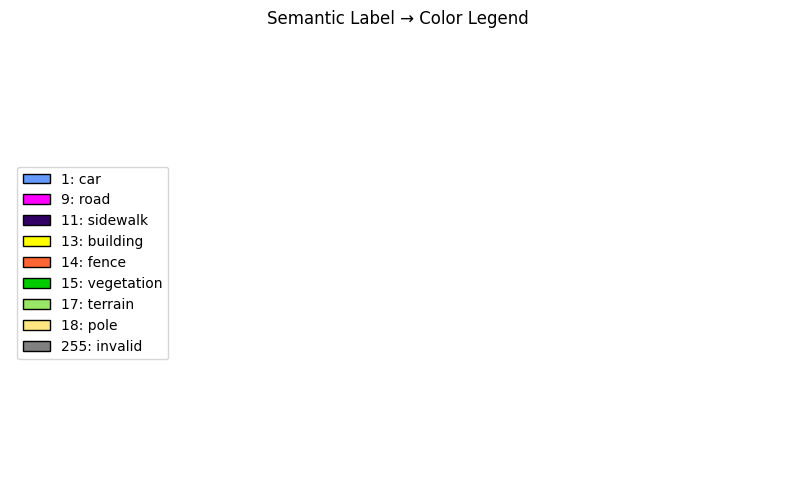

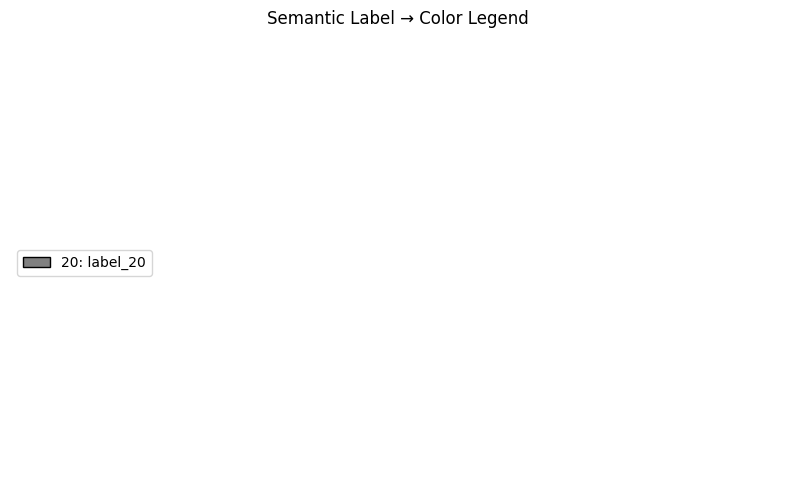

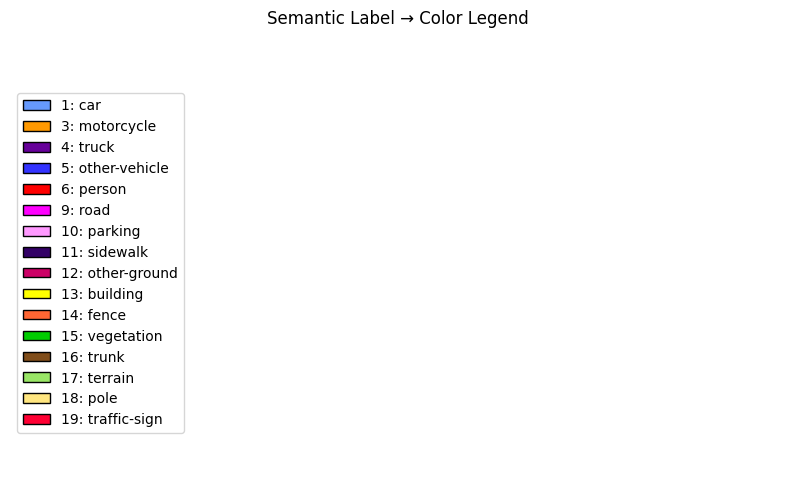

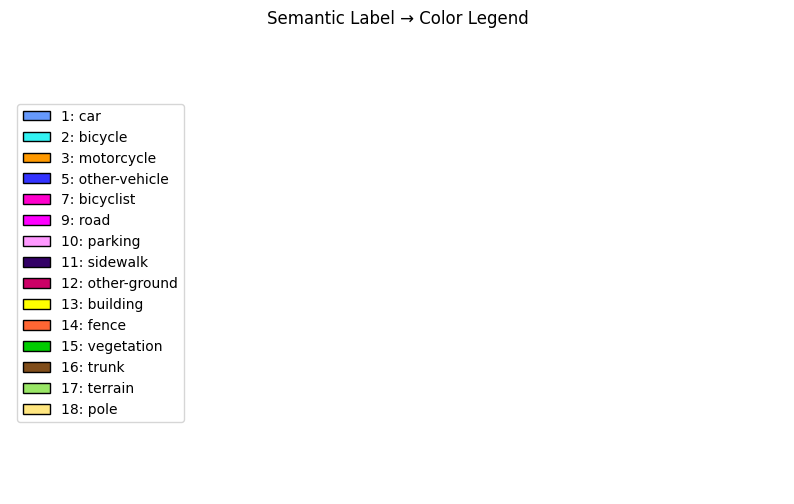

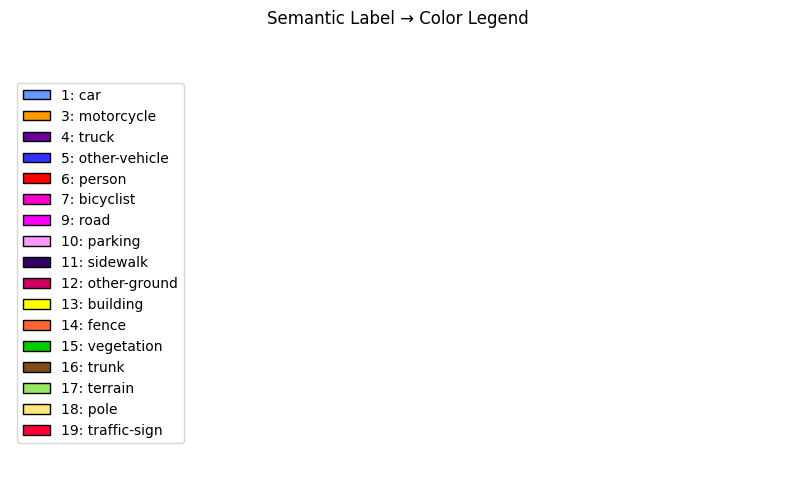

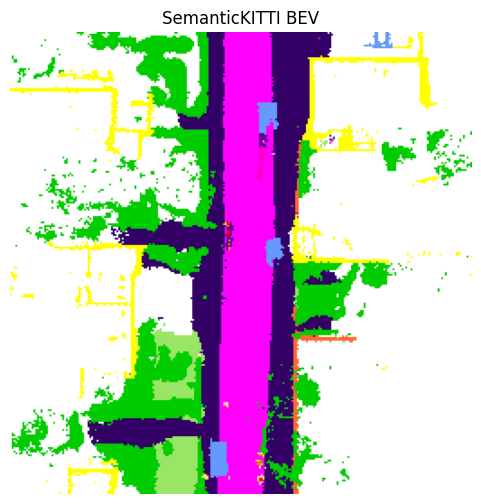

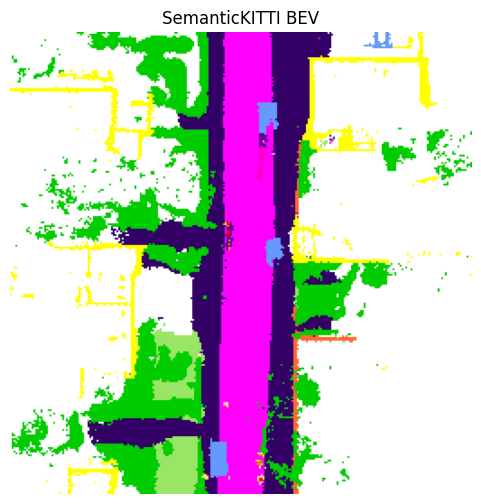

In [39]:
semkitti_colors = {
    0:  [1.0, 1.0, 1.0],        # empty (air) — white
    1:  [0.4, 0.6, 0.99],       # car — light blue
    2:  [0.2, 0.95, 0.95],      # bicycle — cyan
    3:  [1.0, 0.6, 0.0],        # motorcycle — orange
    4:  [0.4, 0.0, 0.6],        # truck — dark purple
    5:  [0.2, 0.2, 1.0],        # other-vehicle — blue
    6:  [1.0, 0.0, 0.0],        # person — red
    7:  [1.0, 0.0, 0.8],        # bicyclist — pink-red
    8:  [1.0, 0.0, 1.0],        # motorcyclist — fuchsia
    9:  [1.0, 0.0, 1.0],        # road — magenta
    10: [1.0, 0.6, 1.0],        # parking — light pink
    11: [0.2, 0.0, 0.4],        # sidewalk — dark purple
    12: [0.8, 0.0, 0.4],        # other-ground — dark red
    13: [1.0, 1.0, 0.0],        # building — yellow
    14: [1.0, 0.4, 0.2],        # fence — orange-red
    15: [0.0, 0.8, 0.0],        # vegetation — green
    16: [0.5, 0.3, 0.1],        # trunk — brown
    17: [0.6, 0.9, 0.4],        # terrain — light green
    18: [1.0, 0.9, 0.5],        # pole — pale yellow
    19: [1.0, 0.0, 0.2],        # traffic sign — bright red
    20: [0.5, 0.5, 0.5],        # invalid — gray
    255: [0.5, 0.5, 0.5],
}
bev = bev_topdown(recon_voxel[0])   # [256,256] from your function
%matplotlib inline
visualize_bev(bev, semkitti_colors)


In [30]:
# vox = recon_voxel[0]
# intersection = (vox.detach().cpu() != 0) & (gt != 0)
# print(intersection.sum() /  (gt != 0).sum())
# vox[gt == 20] = 20
# visualize_kitti_instance(vox)

In [133]:
gt = velodene_to_voxel( "/home/brendan/SemCityOcto/dataset/", "00", "000000")
# gt[gt != 0] = 20
visualize_kitti_instance(torch.tensor(gt).cuda())

Loading data for sequence 00, scan 000000...


In [32]:
visualize_kitti_instance(torch.tensor(gt).cuda())

In [33]:
def assign_octree_patch_features(vox_patches, octree, depth, patch_size=4):  
    """
    voxel_tensor: [128, 128, 32]  # dense semantic map
    octree: ocnn.Octree
    depth: target depth (e.g., 5 for 32×32×32)
    output: octree.features[depth] ← shape: [nnum[depth], 4, 4]
    """
    device = vox_patches.device
    grid_size = 2 ** depth  # = 32

    # Step 1: reshape to patch grid [32, 32, 32, 4, 4]


    # Step 2: flatten spatial index
    i = torch.arange(grid_size, dtype=torch.int32, device=device)
    j = torch.arange(grid_size, dtype=torch.int32, device=device)
    k = torch.arange(grid_size, dtype=torch.int32, device=device)
    ii, jj, kk = torch.meshgrid(i, j, k, indexing='ij')  # [32, 32, 32]
    xyz = torch.stack([ii, jj, kk], dim=-1).reshape(-1, 3)  # [32768, 3]
    batch = torch.zeros((xyz.size(0), 1), dtype=torch.int32, device=device)
    xyzb = torch.cat([xyz, batch], dim=1)  # [32768, 4]

    # Step 3: search octree index
    idxs = octree.search_xyzb(xyzb, depth=depth, nempty=False)  # [32768]
    valid = idxs != -1
    valid_idxs = idxs[valid].long()

    # Step 4: flatten patch features
    vox_patches_flat = vox_patches.reshape(-1, patch_size, patch_size)  # [32768, 4, 4]
    valid_feats = vox_patches_flat[valid].to(torch.int32)               # [n_valid, 4, 4]

    # Step 5: assign to octree
    octree.features[depth] = torch.zeros((octree.nnum[depth], patch_size, patch_size), device=device, dtype=torch.int32)
    octree.features[depth][valid_idxs] = valid_feats


In [34]:
OFFSET = 0
non_empty_mask_padded = torch.zeros((64,64,64))
non_empty_mask_padded[:,:,OFFSET:OFFSET+32] = non_empty_mask
visualize_kitti_instance(non_empty_mask_padded)
from utils.util_octree_stuff import *
patch_padded = torch.zeros((64,64,64,4,4))
vox = torch.tensor(gt).unsqueeze(0)
vox[vox == 255] = 0

patch = voxel_to_patch(vox, 4)
patch_padded[:,:,OFFSET:OFFSET+32,:,:] = patch[0]
points = voxel_grid_to_points(non_empty_mask_padded)
octree = points2octree(points,depth=6,full_depth=3)
assign_octree_patch_features(patch_padded,octree, 6)


In [35]:
output = vae(octree.cuda(), octree_out=octree.cuda(), pos=None, evaluate=False, update_octree=False)
recon_voxel = reconstruct_voxel_from_patch(output['sem_voxs'], output['octree_out'], depth=6, shape=(1, 256, 256, 32), patch_size=4)

visualize_kitti_instance(recon_voxel[0])

/home/brendan/miniconda3/envs/octfusion/lib/python3.11/site-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


In [36]:
z_gt,mu_gt,doctree_gt = vae.extract_code(octree.cuda())

In [37]:
import torch

def filter_nonempty_patches(patch, threshold=14):
    """
    Filter 4x4 patches based on number of non-zero elements.

    Args:
        patch: torch.Tensor [64, 64, 64, 4, 4] of integers.
        threshold: int, minimum number of non-zero elements required to keep.

    Returns:
        keep_indices: torch.Tensor [N, 3] of (x,y,z) coords kept.
        filtered_patch: torch.Tensor [64, 64, 64, 4, 4] with failing patches zeroed out.
    """
    assert patch.ndim == 5 and patch.shape[-2:] == (4, 4), \
        "Input must be [64, 64, 64, 4, 4]"

    # Count nonzero per patch
    nonzero_count = (patch != 0).sum(dim=(-1, -2))  # [64, 64, 64]

    # Boolean mask for which patches to keep
    keep_mask = nonzero_count > threshold           # [64, 64, 64]

    # Get indices of patches to keep
    keep_indices = torch.nonzero(keep_mask, as_tuple=False)  # [N, 3]

    # Create filtered version
    filtered_patch = patch.clone()
    filtered_patch[~keep_mask] = 0  # zero out patches that don't pass

    return keep_indices, filtered_patch


In [120]:

indices, filtered_patch = filter_nonempty_patches(patch_padded, threshold=10)
print(f"Kept {len(indices)} patches.")
print("First few kept indices:", indices[:5])


Kept 170 patches.
First few kept indices: tensor([[ 0, 23,  2],
        [ 0, 23,  3],
        [ 0, 23,  4],
        [ 0, 23,  5],
        [ 0, 23,  6]])


In [121]:
vox_from_filtered_patch = patch_to_voxel(filtered_patch.unsqueeze(0))

In [122]:
visualize_kitti_instance(vox_from_filtered_patch[0])

/home/brendan/SemCityOcto/util_octree_stuff.py:539: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [123]:
vox_from_filtered_patch.shape

torch.Size([1, 256, 256, 64])

In [66]:
# octree_known_recon = vae.create_child_octree(octree_known).cuda()
# doctree = DualOctree(octree_known_recon )
# doctree.post_processing_for_docnn()
# z_rand = torch.randn(doctree.total_num, LATENT_DIM)
# z_T = z_rand.cuda()

In [86]:
z_gt = torch.randn_like(z_rand).cuda()
mask = torch.zeros_like(z_gt).cuda()

In [87]:
octree_cpu = octree_known_recon.cpu()
octree_vae_cpu = octree.cpu()

In [88]:
octree_cpu.nnum,octree_vae_cpu.nnum

(tensor([    1,     8,    64,   512,  4096,  6296, 27384], dtype=torch.int32),
 tensor([    1,     8,    64,   512,   712,  3416, 15736], dtype=torch.int32))

In [89]:

cnt = 0
offset = doctree.total_num - doctree.nnum[6]
offset_vae = doctree_gt.total_num - doctree_gt.nnum[6]


In [90]:
offset,offset_vae

(tensor(6182, dtype=torch.int32), tensor(2157, dtype=torch.int32))

In [91]:
for i in range(indices.shape[0]):

    q = F.pad(indices[i], (0, 1)) 
    idx =octree_cpu.search_xyzb(q.unsqueeze(0), depth=6)
    if idx  == -1:
        cnt += 1
    else:
        idx_vae = octree_vae_cpu.search_xyzb(q.unsqueeze(0), depth=6)
        if idx_vae+offset_vae > mu_gt.shape[0]:
            print("1")
            break
        latent_feature = mu_gt[idx_vae+offset_vae] 
        idx = octree_cpu.search_xyzb(q.unsqueeze(0), depth=6)
        if idx + offset > z_gt.shape[0]:
            print("2")
            break
        z_gt[offset + idx] = latent_feature.cuda()
        mask[offset + idx] = 1

In [92]:
@torch.no_grad()
def ddim_sample_logsnr_cosine_inpaint(z_T,z_gt, model,mask, doctree, S=50, jump_n_sample = 10,predict_mode="x0"):
    """
    DDIM sampling using cosine logSNR schedule and x₀ prediction.

    Args:
        z_T: Initial noise tensor [N, C]
        model: Trained diffusion model
        doctree: DualOctree structure
        S: Number of DDIM steps (e.g., 50)
        predict_mode: "x0" (only supported here)
    """
    assert predict_mode == "x0", "Only x0 mode is supported in this version."

    # === Step 1: Generate continuous t schedule [1.0, ..., 0.0]
    t_steps = torch.linspace(1., 0., S + 1, device=z_T.device)  # [S+1]
    t_pairs = list(zip(t_steps[:-1], t_steps[1:]))


    z_t = z_T
    for t, t_next in t_pairs:
        # Convert scalars to tensors
        for j in range(jump_n_sample): 
            t_tensor = t.view(1, 1)
            t_next_tensor = t_next.view(1, 1)

            logsnr_t = alpha_cosine_log_snr(t_tensor)
            logsnr_next = alpha_cosine_log_snr(t_next_tensor)

            alpha_t, sigma_t = log_snr_to_alpha_sigma(logsnr_t)
            alpha_next, sigma_next = log_snr_to_alpha_sigma(logsnr_next)
            # Inpaint
            noised_z_gt = (z_gt * alpha_next + sigma_next * torch.randn_like(z_gt))
            x0_pred = model(z_t, doctree=doctree, timesteps=t_tensor)  # Predict x0
            x0_pred = ( mask) * noised_z_gt + (1-mask) * x0_pred
            # DDIM update rule
            z_t = alpha_next * x0_pred + sigma_next * torch.randn_like(z_t)
            if j < jump_n_sample - 1 and t > 1:
                noise_back = torch.randn_like(z_t)
                # noised_data = alpha_t * noised_data + sigma_t * noise_back
                z_t = alpha_t * z_t + sigma_t * noise_back
            
    return z_t


In [93]:
z_T = torch.randn_like(z_gt)
z_sampled_outpaint = ddim_sample_logsnr_cosine_inpaint(z_T,z_gt, unet_model,mask,doctree, S=50,jump_n_sample=5, predict_mode="x0")

In [95]:
(indices.shape[0])

170

In [96]:
z.shape

NameError: name 'z' is not defined

In [97]:
doctree.total_num

33566

In [98]:
octree.nnum

tensor([    1,     8,    64,   512,   712,  3416, 15736], dtype=torch.int32)

In [99]:
octree.nnum_nempty

tensor([    1,     8,    64,    89,   427,  1967, 10115], dtype=torch.int32)

In [100]:
output = vae.decode_code(z_sampled_outpaint.cuda(), doctree, update_octree=False, pos=None)
recon_voxel = reconstruct_voxel_from_patch(output['sem_voxs'], octree_cpu.cuda(), depth=6, shape=(1, 256, 256, 32), patch_size=4)

In [102]:
visualize_kitti_instance(recon_voxel[0])

In [114]:
vox_new.shape

torch.Size([1, 256, 256, 64])

In [117]:
visualize_kitti_instance(gt)

/home/brendan/SemCityOcto/util_octree_stuff.py:539: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [131]:
# Assuming:
# gt is a torch.Tensor with shape [H, W, D] (e.g., [256, 256, 32])
# vox_from_filtered_patch is another tensor of same shape

mask = (vox_from_filtered_patch[0][:,:,0:32] == 0) & (gt != 0)
gt[mask] = 20


/tmp/ipykernel_209886/53474816.py:5: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  mask = (vox_from_filtered_patch[0][:,:,0:32] == 0) & (gt != 0)


In [132]:
visualize_kitti_instance(gt)

In [126]:
gt.shape

(256, 256, 32)

In [127]:
mask.shape

torch.Size([256, 256, 32])

In [134]:
gt[32:, :, :][gt[32:, :, :] != 0] = 20


In [135]:
visualize_kitti_instance(gt)

/home/brendan/SemCityOcto/util_octree_stuff.py:539: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [ ]:
visualize_kitti_instance(recon_voxel[0])